# 3 - Data Density & Participation
This notebook examines response volume, temporal density, and participation stability across waves.
Visuals: per-participant ESM count · daily response rate · weekly participation rate · cumulative response curve

## Import libraries and define paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline

np.random.seed(42)

from utils import (
    COLORS, WAVE_LABELS, WAVE_KEYS,
    get_data_root, set_paper_style,
)

DATA_ROOT = get_data_root()
set_paper_style()


## Load data

In [2]:
from utils import esm_counts_per_person, load_esm_28d, load_sensor_28d

df_X_28d, df_X_28d_stats = load_sensor_28d(DATA_ROOT, wave_keys=WAVE_KEYS)


## Data processing

In [3]:
_, _, esm_all_28d, esm_by_wave_28d, esm_28d_stats = load_esm_28d(
    wave_keys=WAVE_KEYS,
    data_root=DATA_ROOT,
    include_userinfo=False,
    include_study_day=True,
)


---
## Visual

### Per-Participant ESM Count
Insight: Captures response volume dispersion across participants.

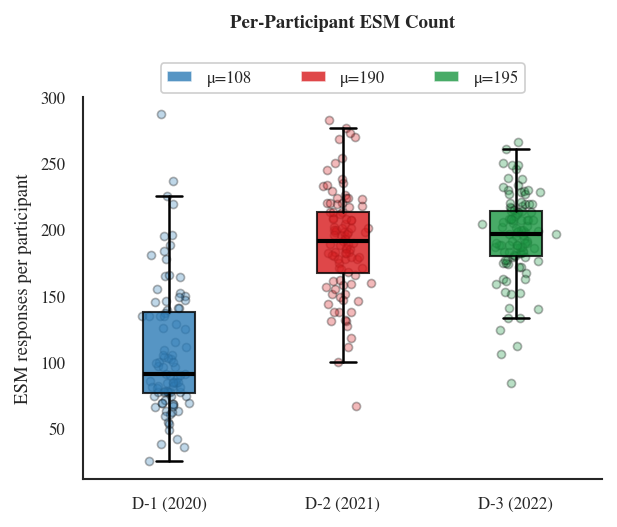

In [39]:
# Build per-wave arrays of response counts; drop empty waves
esm_series  = [esm_counts_per_person(esm_by_wave_28d[k]) for k in WAVE_KEYS]
valid_mask  = [arr.size > 0 for arr in esm_series]
esm_series  = [arr  for arr, ok in zip(esm_series,  valid_mask) if ok]
active_keys = [key  for key, ok in zip(WAVE_KEYS,   valid_mask) if ok]
active_lbls = [lbl  for lbl, ok in zip(WAVE_LABELS, valid_mask) if ok]

fig, ax = plt.subplots(figsize=(4.0, 3.4), constrained_layout=True)

if esm_series:
    bp = ax.boxplot(
        esm_series, patch_artist=True, showfliers=False,
        medianprops=dict(color="black", lw=2),
        whiskerprops=dict(lw=1.2),
        capprops=dict(lw=1.2),
    )
    for patch, key in zip(bp["boxes"], active_keys):
        patch.set_facecolor(COLORS[key])
        patch.set_alpha(0.8)

    np.random.seed(42)
    for i, arr in enumerate(esm_series, start=1):
        x = np.random.normal(loc=i, scale=0.06, size=len(arr))
        ax.scatter(x, arr, s=15, alpha=0.3, color=COLORS[active_keys[i - 1]], edgecolors="black")

    ax.set_xticks(range(1, len(active_lbls) + 1))
    ax.set_xticklabels(active_lbls)
    ax.set_ylabel("ESM responses per participant")
    ax.set_title("Per-Participant ESM Count", fontweight="bold", fontsize=9, y=1.15)

    legend_handles = [
        mpatches.Patch(
            facecolor=COLORS[active_keys[i]], alpha=0.8,
            label=f"μ={np.mean(esm_series[i]):.0f}",
        )
        for i in range(len(esm_series))
    ]
    ax.legend(handles=legend_handles, loc="lower center", fontsize=8,
              frameon=True,
              framealpha=0.95,
              bbox_to_anchor=(0.5, 1.01), ncol=len(legend_handles),
              borderaxespad=0, handlelength=1.5, columnspacing=3)
else:
    ax.text(0.5, 0.5, "no data", ha="center", va="center",
            transform=ax.transAxes, color="gray")
    ax.set_axis_off()

plt.show()

### Daily Response Rate by Study Day

This line plot shows per-participant ESM response rate across study days for each wave.


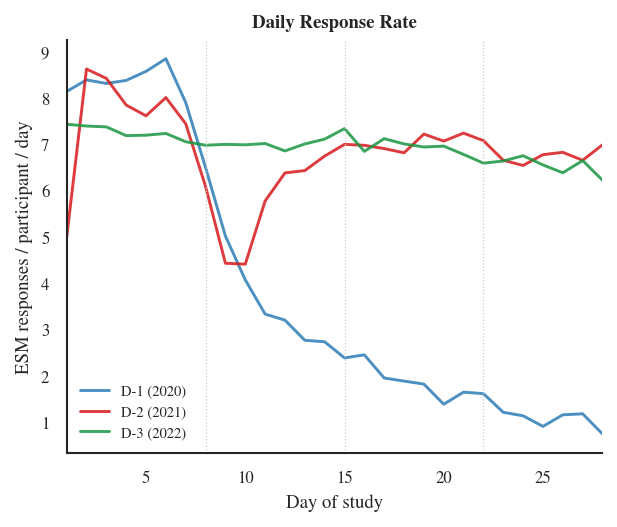

In [6]:
WEEK_BOUNDARIES = [8, 15, 22]   # day numbers marking week boundaries
STUDY_DAYS      = np.arange(1, 29)

fig, ax = plt.subplots(figsize=(4.0, 3.4), constrained_layout=True)

for k_idx, wave in enumerate(WAVE_KEYS):
    if esm_all_28d.empty or "study_day" not in esm_all_28d.columns:
        continue
    sub = esm_all_28d[esm_all_28d["Wave"] == wave]
    n_participants = sub["Pcode"].nunique()
    daily_rate = (
        sub.groupby("study_day").size()
           .reindex(STUDY_DAYS, fill_value=0)
           .div(n_participants)
    )
    ax.plot(STUDY_DAYS, daily_rate.values,
            color=COLORS[wave], lw=1.4, alpha=0.85, label=WAVE_LABELS[k_idx])

for w in WEEK_BOUNDARIES:
    ax.axvline(w, color="#cccccc", lw=0.6, ls=":")

ax.set_xlabel("Day of study")
ax.set_ylabel("ESM responses / participant / day")
ax.set_xlim(1, 28)
ax.set_title("Daily Response Rate", fontweight="bold", fontsize=9)
ax.legend(frameon=False, fontsize=7)
plt.show()

### Daily activity heatmap

This heatmap summarizes the pattern across waves so differences and missingness are easy to compare.


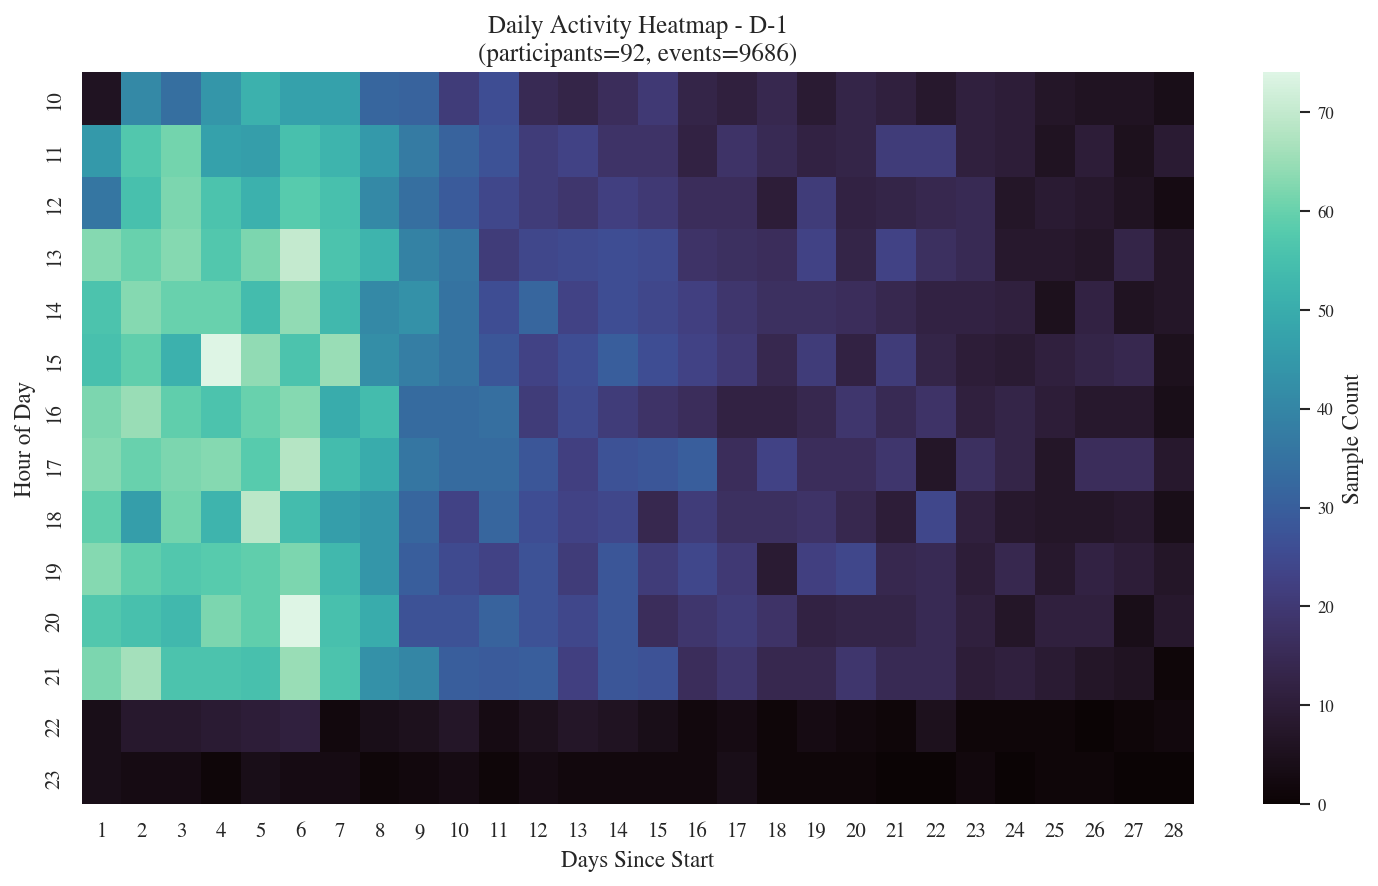

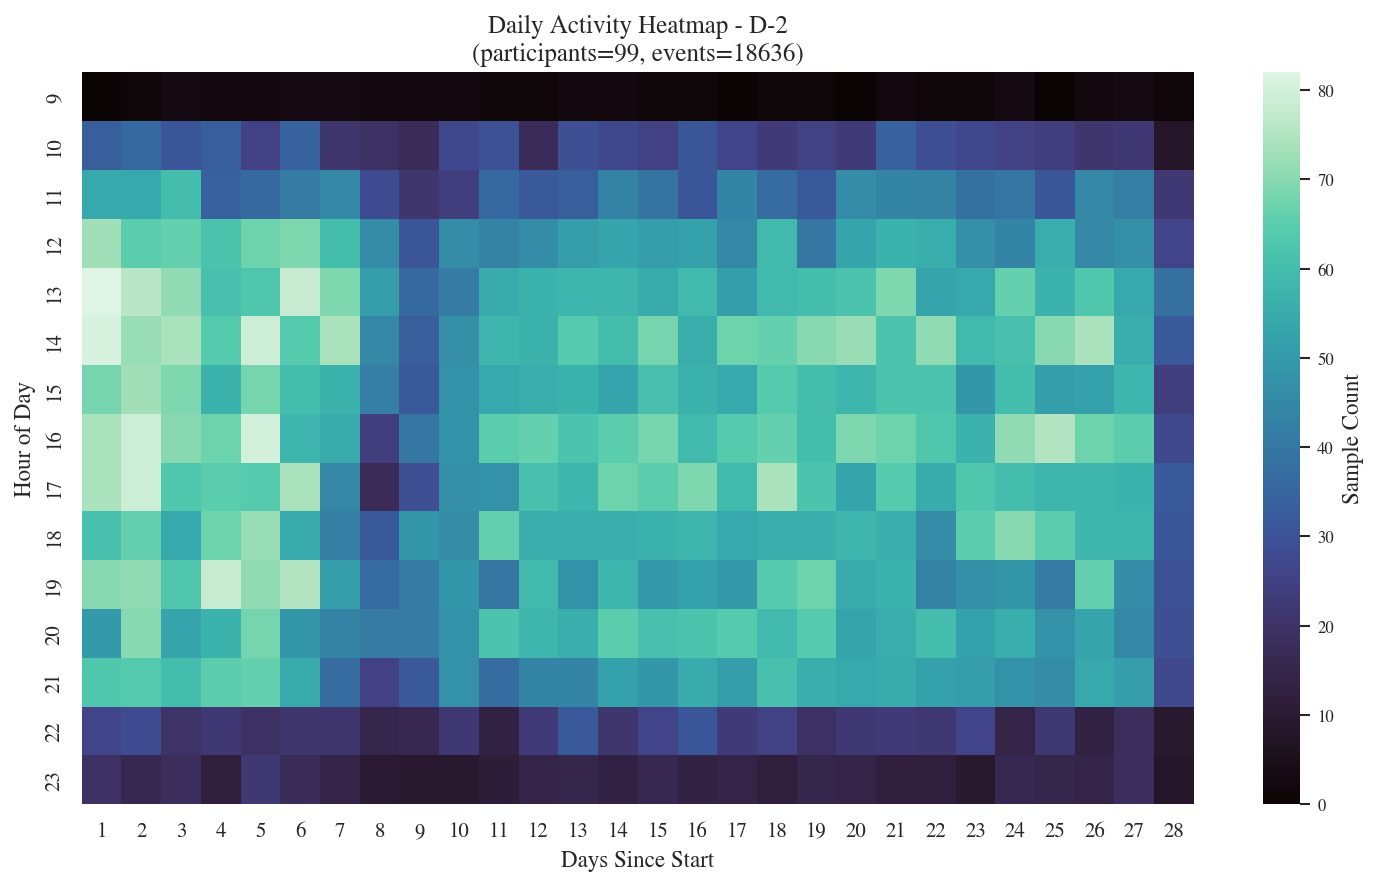

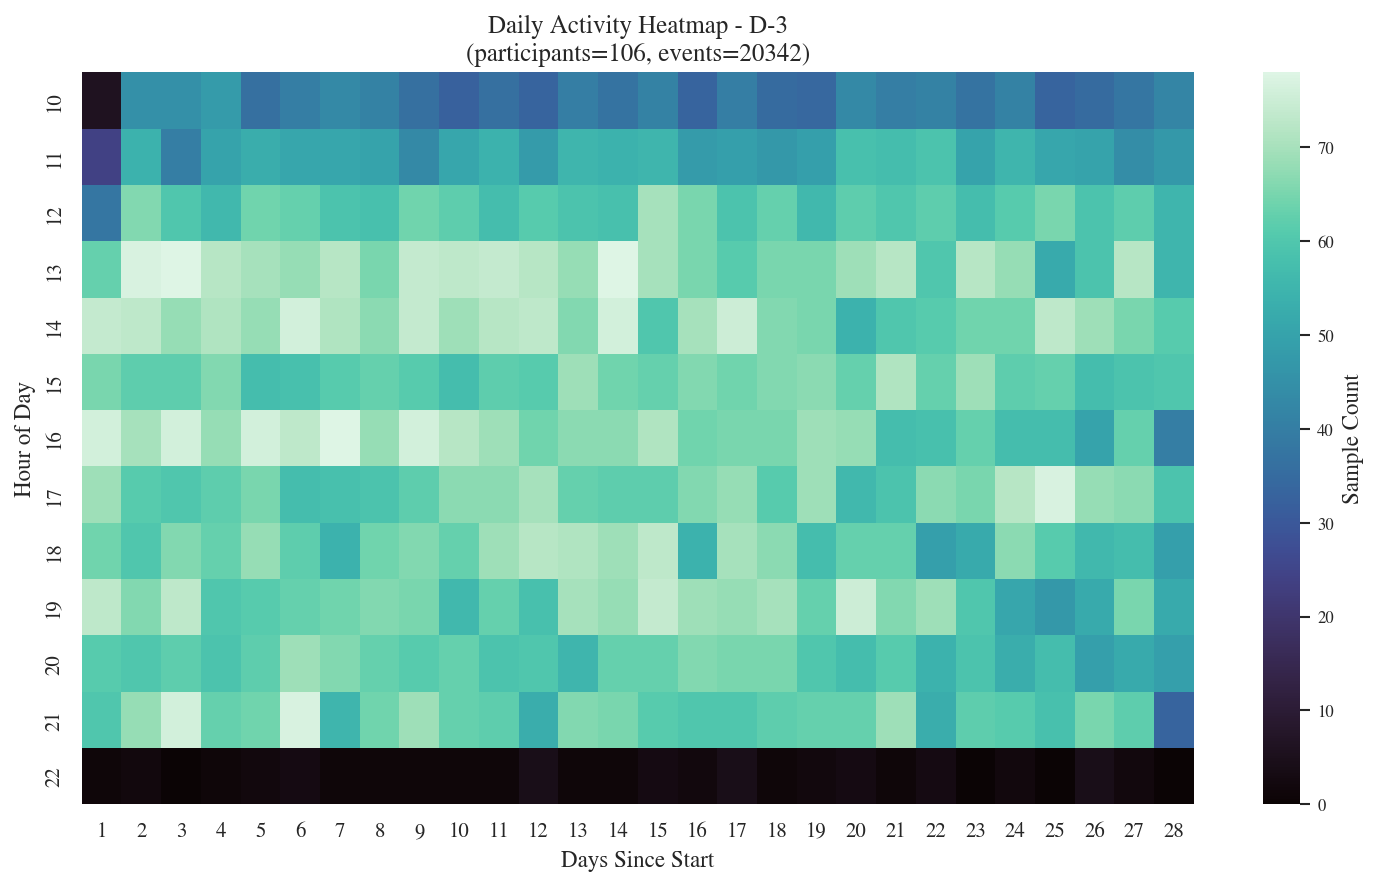

In [7]:
ds_col  = "META#dataset"
ts_col  = "PIF#timestamp"
start_col = "PIF#participationStartTimestamp"
pid_col = "PIF#participantID"

# --- Parse both columns to timezone-aware datetimes in Asia/Seoul ---
ts_dt = pd.to_datetime(df_X_28d[ts_col], errors="coerce", utc=True).dt.tz_convert("Asia/Seoul")
start_dt = pd.to_datetime(df_X_28d[start_col], unit="ms", errors="coerce", utc=True).dt.tz_convert("Asia/Seoul")

ok = ts_dt.notna() & start_dt.notna()
base = df_X_28d.loc[ok, [ds_col, pid_col]].copy()
base = base.assign(
    datetime=ts_dt.loc[ok],
    start_dt=start_dt.loc[ok],
)

delta_days = (base["datetime"] - base["start_dt"]).dt.total_seconds() / 86400.0
base["day_index"] = np.floor(delta_days).astype("int64") + 1
base["hour"] = base["datetime"].dt.hour
base = base[(base["day_index"] >= 1) & (base["day_index"] <= 28)]

# --- run per dataset (D-1/D-2/D-3), inline plotting ---
for ds in ("D-1", "D-2", "D-3"):
    dsub = base.loc[base[ds_col] == ds, ["day_index", "hour", pid_col]]
    if dsub.empty:
        print(f"[skip] {ds}: empty after parsing")
        continue

    heat = (
        dsub.groupby(["day_index", "hour"])
            .size()
            .unstack(fill_value=0)
            .sort_index()
    )

    hour_totals = heat.sum(axis=0)
    valid_hours = hour_totals[hour_totals >= 20].index
    heat = heat[valid_hours]
    if heat.empty:
        print(f"[skip] {ds}: no hours with ≥20 samples")
        continue

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        heat.T, cmap="mako", cbar_kws={"label": "Sample Count"},
        square=False,
    )
    cbar = ax.collections[0].colorbar
    cbar.set_label("Sample Count", fontsize=11)

    plt.title(
        f"Daily Activity Heatmap - {ds}\n"
        f"(participants={dsub[pid_col].nunique()}, events={len(dsub)})",
        fontsize=12,
    )
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    plt.xlabel("Days Since Start", fontsize=11)
    plt.ylabel("Hour of Day", fontsize=11)
    plt.tight_layout()
    plt.show()

### Daily Activity Heatmap (Combined Datasets)

This heatmap aggregates all datasets to show activity intensity by study day and hour.


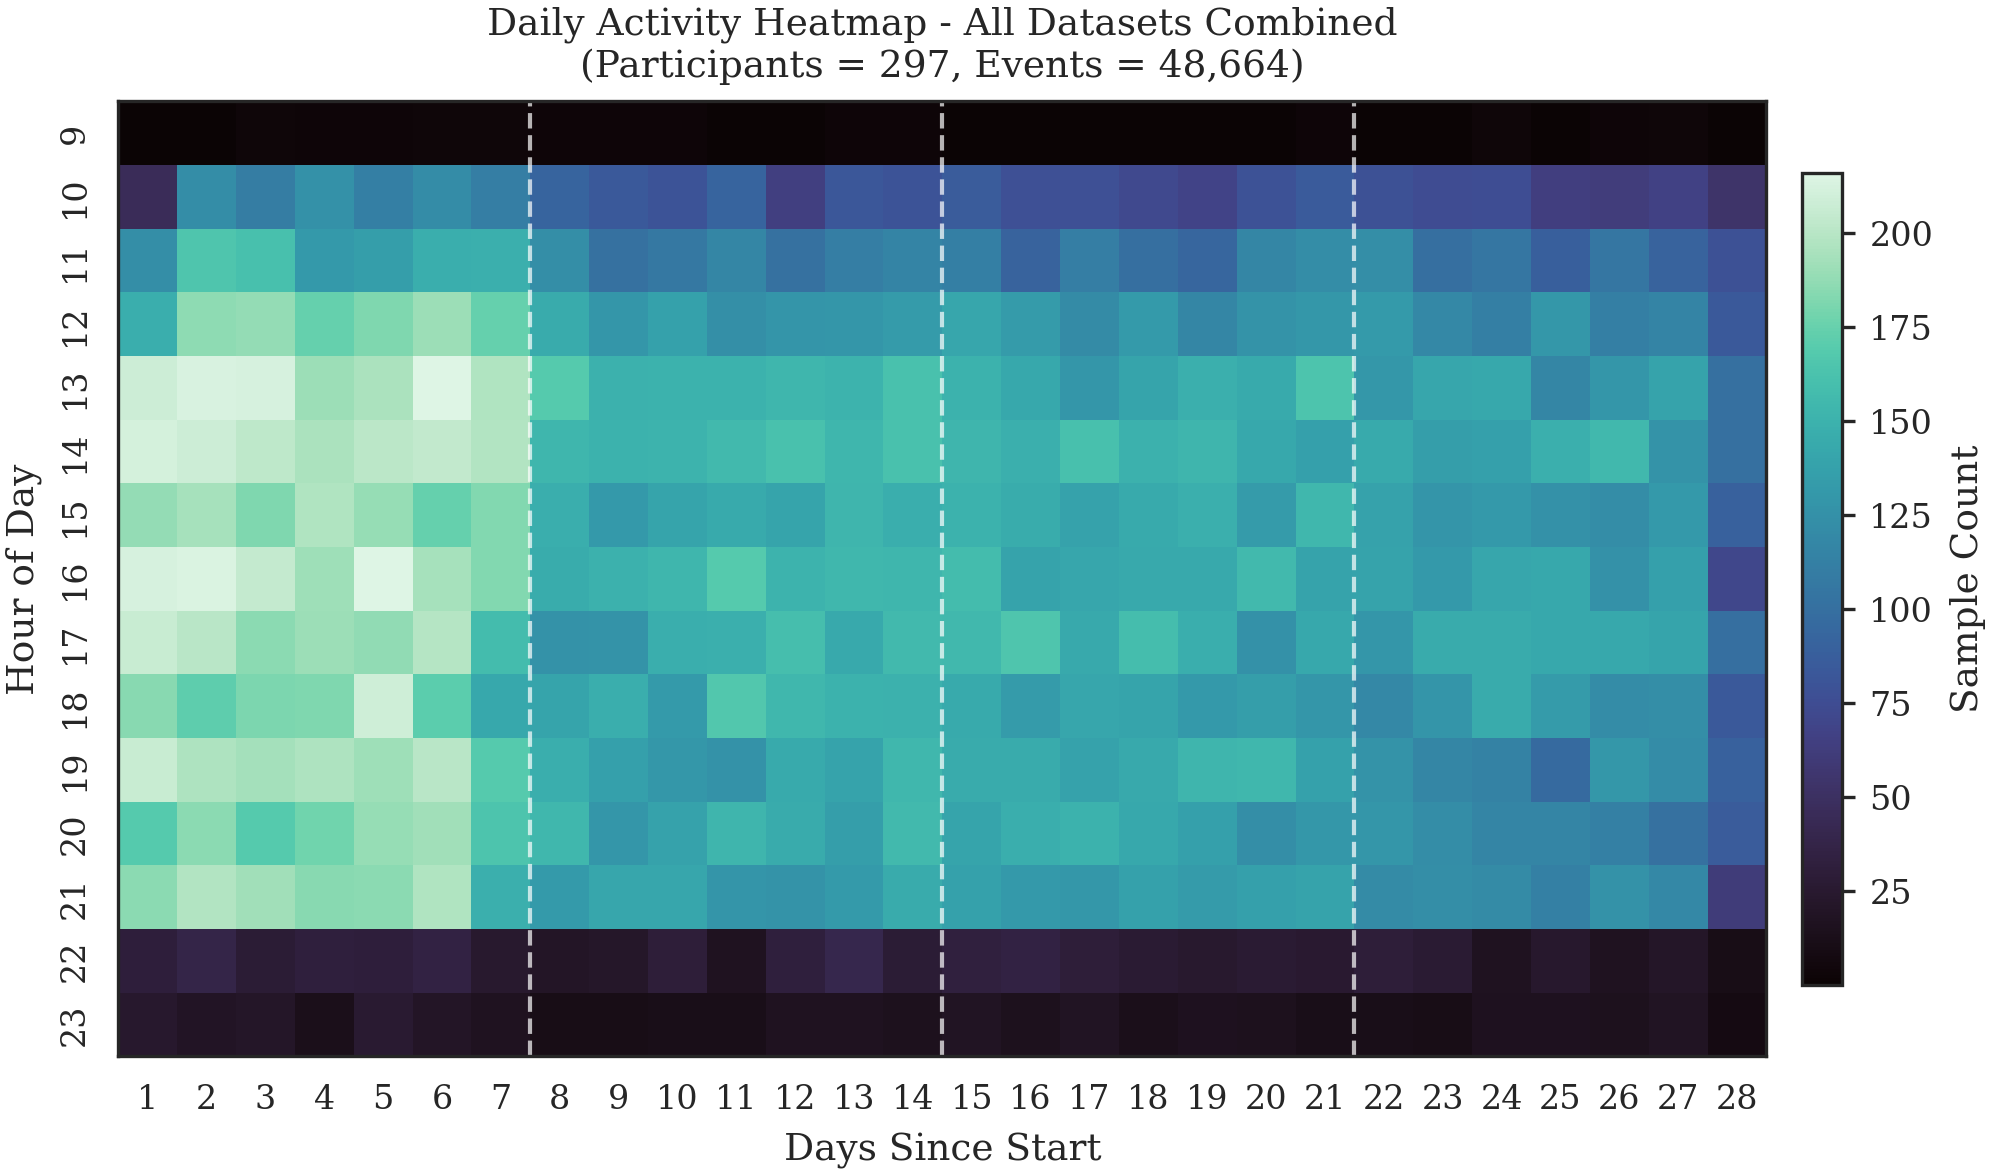

In [8]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
 
# ── NeurIPS-compatible rcParams ───────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          9,
    "axes.titlesize":     9,
    "axes.labelsize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "axes.linewidth":     0.8,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype":       42,   # embeds fonts properly for submission
    "ps.fonttype":        42,
})
 
# ── Reproduce your heatmap data prep (unchanged) ──────────────────────────────
base_combined = base.copy()
base_combined["PIF#participantID"] = (
    base_combined[ds_col] + "_" + base_combined[pid_col].astype(str)
)
if base_combined.empty: 
    print("[skip] All Datasets Combined: empty after parsing")
else:
    heat = (
        base_combined.groupby(["day_index", "hour"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
 
    hour_totals = heat.sum(axis=0)
    valid_hours = hour_totals[hour_totals >= 20].index
    heat = heat[valid_hours]
 
    if heat.empty:
        print("[skip] All Datasets Combined: no hours with ≥20 samples")
    else:
        n_participants = base_combined["PIF#participantID"].nunique()
        n_events       = len(base_combined)
 
        # ── Derive a principled vmin ──────────────────────────────────────────
        # Set vmin to the 5th-percentile of non-zero cells so the colour ramp
        # begins just above "truly empty", making mid-range values (150+)
        # appear visually dense rather than sparse.
        nonzero_vals = heat.values[heat.values > 0]
        # vmin_auto    = float(np.percentile(nonzero_vals, 5)) if len(nonzero_vals) else 0
        vmax_auto    = float(heat.values.max())
        vmin_auto = vmax_auto * 0.001 
        # NeurIPS double-column width = 6.75 in; single col = 3.25 in.
        # A heatmap of this aspect ratio fits well at 6.75 × 4.0.
        fig, ax = plt.subplots(figsize=(6.75, 4.0))
 
        sns.heatmap(
            heat.T,
            ax=ax,
            cmap="mako",
            vmin=vmin_auto,        # ← FIX: anchors colour scale above zero
            vmax=vmax_auto,
            cbar_kws={
                "label":    "Sample Count",
                "shrink":   0.85,
                "pad":      0.02,
                "fraction": 0.046,
            },
            square=False,
            linewidths=0,          # no grid lines between cells
            rasterized=True,       # keeps PDF file size small
        )
        day_indices = list(heat.index)  # sorted list of day_index values in the heatmap
        for week_end in (7, 14, 21):
            if week_end in day_indices:
                x_pos = day_indices.index(week_end) + 1  # +1 because line goes after that day
                ax.axvline(x=x_pos, color="white", linewidth=1.0, linestyle="--", alpha=0.7)

        # Style the colour-bar
        cbar = ax.collections[0].colorbar
        cbar.set_label("Sample Count", fontsize=9)
        cbar.ax.tick_params(labelsize=8, width=0.8, length=3)
        cbar.outline.set_linewidth(0.8)

        ax.set_title(
            f"Daily Activity Heatmap - All Datasets Combined\n"
            f"(Participants = {n_participants:,}, Events = {n_events:,})",
            fontsize=9,
            pad=6,
        )

        ax.set_xlabel("Days Since Start", fontsize=9, labelpad=4)
        ax.set_ylabel("Hour of Day",      fontsize=9, labelpad=4)
 
        # Thin spine frame
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_visible(True)
 
        plt.tight_layout(pad=0.5)

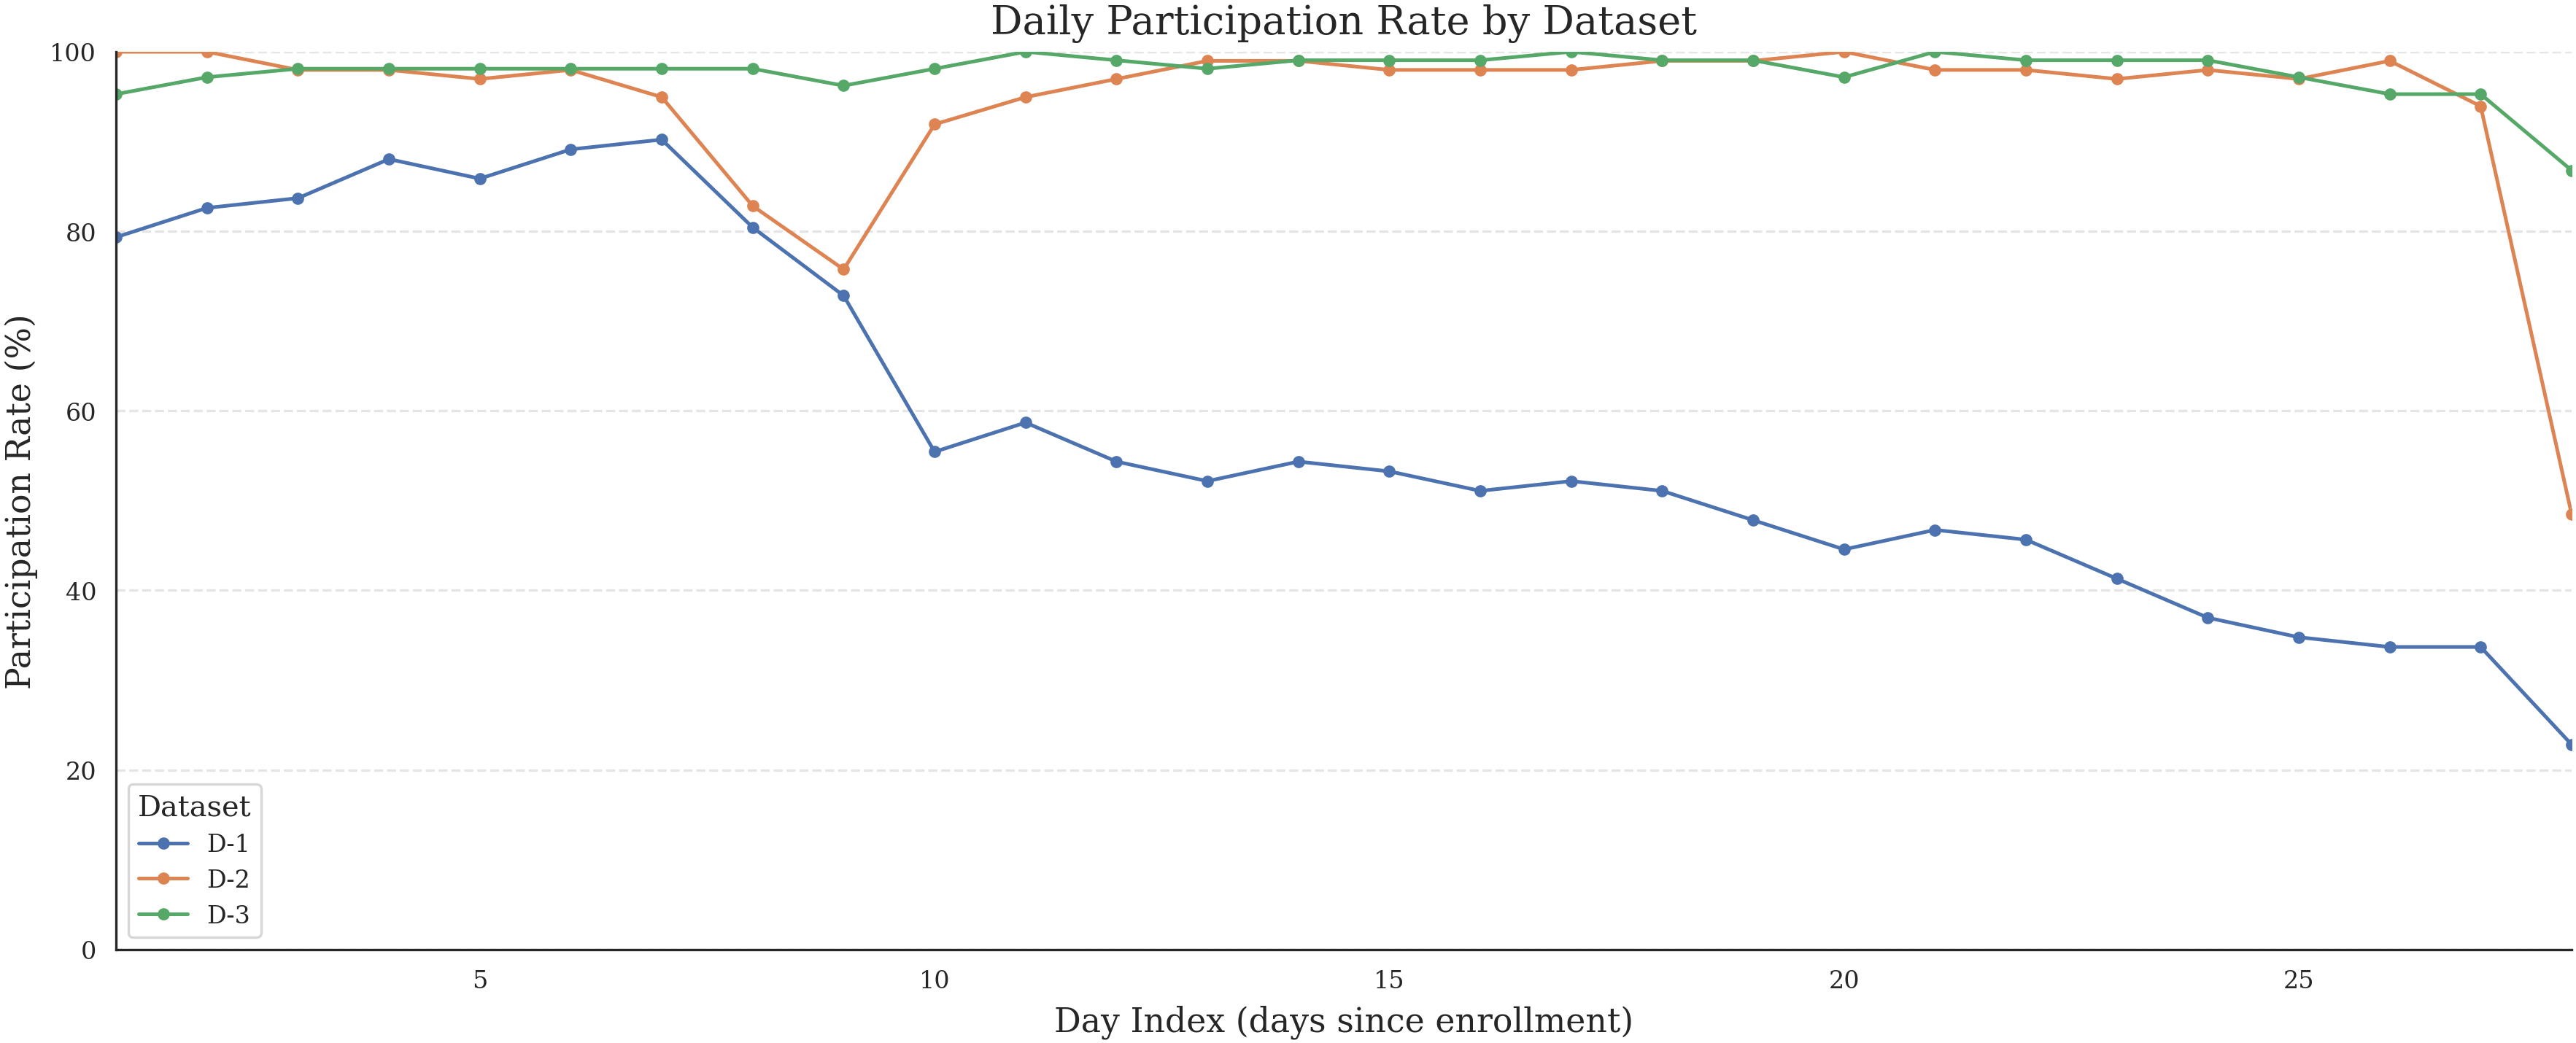

In [9]:
ds_col    = "META#dataset"
ts_col    = "PIF#timestamp"
start_col = "PIF#participationStartTimestamp"
pid_col   = "PIF#participantID"

# --- Parse timestamps ---
ts_dt    = pd.to_datetime(df_X_28d[ts_col], errors="coerce", utc=True).dt.tz_convert("Asia/Seoul")
start_dt = pd.to_datetime(df_X_28d[start_col], unit="ms", errors="coerce", utc=True).dt.tz_convert("Asia/Seoul")

ok   = ts_dt.notna() & start_dt.notna()
base = df_X_28d.loc[ok, [ds_col, pid_col]].copy()
base = base.assign(datetime=ts_dt.loc[ok], start_dt=start_dt.loc[ok])

delta_days      = (base["datetime"] - base["start_dt"]).dt.total_seconds() / 86400.0
base["day_index"] = np.floor(delta_days).astype("int64") + 1
base = base[(base["day_index"] >= 1) & (base["day_index"] <= 28)]

# --- Compute participation rate per dataset per day ---
records = []
for ds in ("D-1", "D-2", "D-3"):
    dsub = base[base[ds_col] == ds]
    if dsub.empty:
        continue

    total_participants = dsub[pid_col].nunique()

    # Unique participants active on each day
    daily_active = (
        dsub.groupby("day_index")[pid_col]
            .nunique()
            .reindex(range(1, 29), fill_value=0)  # ensure all 28 days present
            .reset_index()
    )
    daily_active.columns = ["day_index", "active_participants"]
    daily_active["total_participants"] = total_participants
    daily_active["participation_rate"]  = daily_active["active_participants"] / total_participants * 100
    daily_active["dataset"] = ds
    records.append(daily_active)

part_df = pd.concat(records, ignore_index=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

for ds, grp in part_df.groupby("dataset"):
    ax.plot(grp["day_index"], grp["participation_rate"], marker="o", markersize=3, label=ds)

ax.set_xlim(1, 28)
ax.set_ylim(0, 100)
ax.set_xlabel("Day Index (days since enrollment)", fontsize=11)
ax.set_ylabel("Participation Rate (%)", fontsize=11)
ax.set_title("Daily Participation Rate by Dataset", fontsize=13)
ax.legend(title="Dataset")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Prompt to response delay distribution

This line-based view shows how the metric changes across waves, study days, or participant groups.


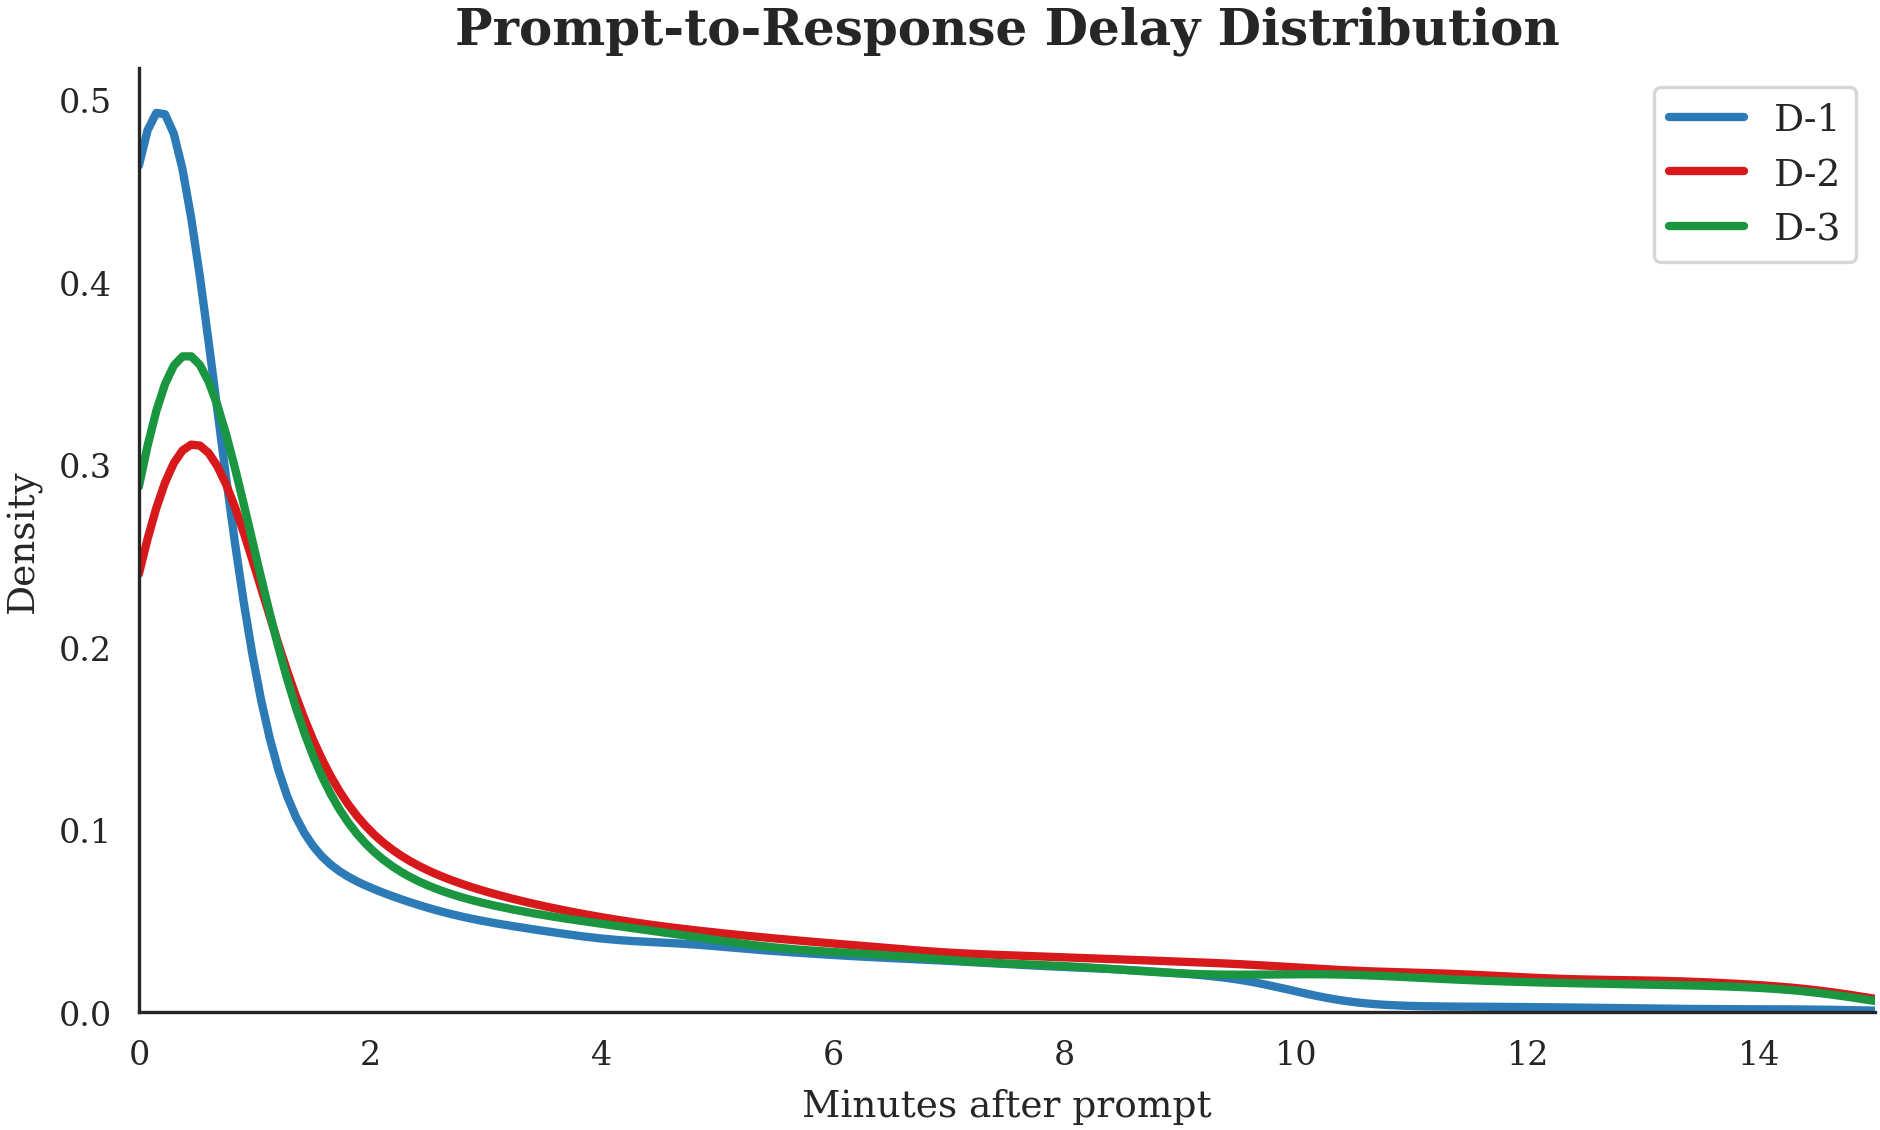

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
esm_by_ds = {}
for name, df in esm_by_wave.items():
    if df.empty:
        continue
    if "TriggerTime" not in df.columns or "ReactionTime" not in df.columns:
        continue
    dsub = df.dropna(subset=["TriggerTime", "ReactionTime"]).copy()
    dsub["response_delay_min"] = (dsub["ReactionTime"] - dsub["TriggerTime"]).dt.total_seconds() / 60
    dsub = dsub[dsub["response_delay_min"] > 0]
    esm_by_ds[name] = dsub
all_delays = pd.concat([d["response_delay_min"] for d in esm_by_ds.values()], ignore_index=True)
x_max = all_delays.max()
# np.nanpercentile(all_delays, 95) if len(all_delays) else 60
for name, df in esm_by_ds.items():
    delays = df["response_delay_min"]
    if len(delays) > 1:
        sns.kdeplot(
            delays, ax=ax, color=COLORS[name],
            linewidth=2, label=name, bw_adjust=1.1, clip=(0, x_max)
        )
ax.set_title("Prompt-to-Response Delay Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Minutes after prompt")
ax.set_ylabel("Density")
ax.set_xlim(0, x_max)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Aligned 28-day window (per-dataset earliest response)

Align each participant's responses to the dataset's earliest response date, then count responses within the first 28 aligned days.

In [4]:
ds_col = "META#dataset"
ts_col = "PIF#timestamp"
pid_col = "PIF#participantID"

# Parse response timestamps (PIF#timestamp) to timezone-aware datetimes
ts_dt = pd.to_datetime(df_X_28d[ts_col], errors="coerce", utc=True).dt.tz_convert("Asia/Seoul")
ok = ts_dt.notna()
base = df_X_28d.loc[ok, [ds_col, pid_col]].copy()
base = base.assign(timestamp=ts_dt.loc[ok])

rows = []
for ds in ("D-1", "D-2", "D-3"):
    dsub = base[base[ds_col] == ds].copy()
    if dsub.empty:
        rows.append({"dataset": ds, "responses_28d": 0})
        continue

    anchor_date = dsub["timestamp"].dt.normalize().min()
    user_start_date = dsub.groupby(pid_col)["timestamp"].transform(lambda s: s.dt.normalize().min())
    day_offset = (user_start_date - anchor_date).dt.days
    aligned_timestamp = dsub["timestamp"] - pd.to_timedelta(day_offset, unit="D")

    window_end = anchor_date + pd.Timedelta(days=27)
    in_window = (aligned_timestamp.dt.normalize() >= anchor_date) & (aligned_timestamp.dt.normalize() <= window_end)

    responses_28d = int(in_window.sum())
    rows.append({"dataset": ds, "responses_28d": responses_28d})

aligned_28d_counts = pd.DataFrame(rows)